Apr 15 14:09:13.972 INFO connect to tikv endpoint: "127.0.0.1:20160"
Fetched 1000 images in 25.5 ms  (39231 reads/sec)


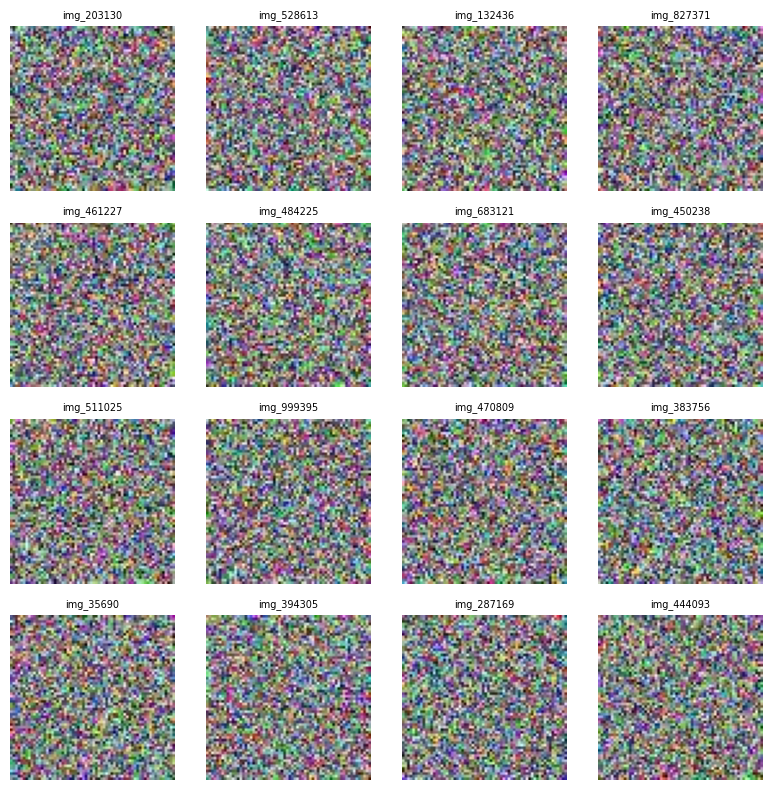

In [1]:
import io
import time
import random
import nest_asyncio
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tikv_client import RawClient

nest_asyncio.apply()

TIKV_ENDPOINTS = ["127.0.0.1:2379"]
TOTAL_IMAGES = 1_000_000
N = 1000  # number of random images to fetch and plot
N_PLOT = 16  # number of images to plot (subset of N)
client = RawClient.connect(TIKV_ENDPOINTS)

# Pick N random keys
keys = [f"img_{i}".encode() for i in random.sample(range(TOTAL_IMAGES), N)]

# Time the batch fetch
start = time.perf_counter()
kv_pairs = client.batch_get(keys)
elapsed = time.perf_counter() - start

images = {k: v for k, v in kv_pairs}

print(f"Fetched {N} images in {elapsed*1000:.1f} ms  ({N/elapsed:.0f} reads/sec)")

# Decode and plot
cols = 4
rows = (N_PLOT + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = np.array(axes).flatten()

for ax, key in zip(axes, keys[:N_PLOT]):
    jpeg_bytes = images[key]
    arr = np.array(Image.open(io.BytesIO(jpeg_bytes)))
    ax.imshow(arr)
    ax.set_title(key.decode(), fontsize=7)
    ax.axis("off")

for ax in axes[N:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


Fetched 1000 images in 184.7 ms  (5413 reads/sec)


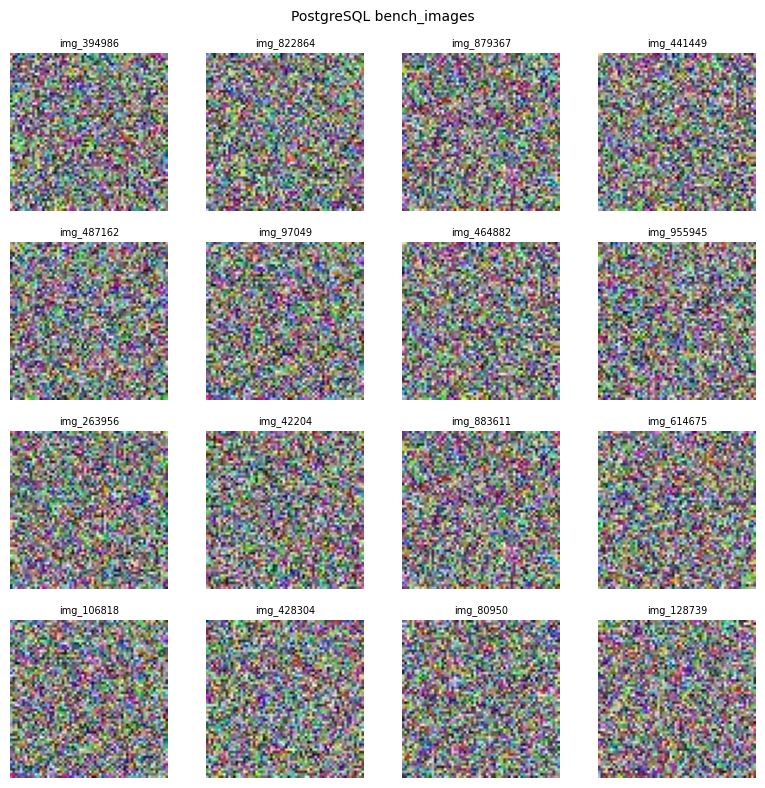

In [2]:
import io
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import psycopg2
from PIL import Image

DB_HOST     = os.environ.get('DB_HOST',     'prototyping-pg-1')
DB_NAME     = os.environ.get('DB_NAME',     'testdb')
DB_USER     = os.environ.get('DB_USER',     'testuser')
DB_PASSWORD = os.environ.get('DB_PASSWORD', 'mypassword')
DSN = f'dbname={DB_NAME} user={DB_USER} password={DB_PASSWORD} host={DB_HOST}'

PG_TOTAL_IMAGES = 1_000_000
N_PG = 1000  # number of random images to fetch and plot
N_PLOT = 16

sample_ids = random.sample(range(PG_TOTAL_IMAGES), N_PG)

conn = psycopg2.connect(DSN)
cur  = conn.cursor()

start = time.perf_counter()
cur.execute('SELECT id, image_data FROM bench_images WHERE id = ANY(%s)', (sample_ids,))
rows = cur.fetchall()
elapsed = time.perf_counter() - start

cur.close()
conn.close()

images_pg = {row[0]: bytes(row[1]) for row in rows}

print(f"Fetched {len(rows)} images in {elapsed*1000:.1f} ms  ({len(rows)/elapsed:.0f} reads/sec)")

# Decode and plot
cols = 4
rows_count = (N_PLOT + cols - 1) // cols
fig, axes = plt.subplots(rows_count, cols, figsize=(cols * 2, rows_count * 2))
axes = np.array(axes).flatten()

for ax, img_id in zip(axes, sample_ids):
    jpeg_bytes = images_pg.get(img_id)
    if jpeg_bytes is None:
        ax.set_visible(False)
        continue
    arr = np.array(Image.open(io.BytesIO(jpeg_bytes)))
    ax.imshow(arr)
    ax.set_title(f"img_{img_id}", fontsize=7)
    ax.axis("off")

for ax in axes[N_PLOT:]:
    ax.set_visible(False)

plt.suptitle("PostgreSQL bench_images", fontsize=10)
plt.tight_layout()
plt.show()
